## NHANES Dataset Analysis - Male participants

This notebook focuses on analyzing the National Health and Nutrition Examination Survey (NHANES) dataset. The dataset can be downloaded at https://wwwn.cdc.gov/nchs/nhanes/. 

The dataset has undergone preprocessing steps which includes removing unnecessary variables as well as missing data. More info in the data directory.

The analysis aims to explore the approach proposed in this paper and identify the relevant features in conditional mean and variance for the waist circunference prediction. Specifically, for male participants.

In [1]:
import sys
sys.path.append("../..")

import math
import numpy as np
import pandas as pd
import sklearn.metrics as skl
from sklearn.model_selection import train_test_split
from knn_bagging import KnnBagging, KnnBag, KnnVar, initialize_knn, roc
import random
import logging
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['axes.labelsize'] = 9

We load the dataset and select the dependent and independent variables we are going to study. We use the same variables for female and male participants. The array `x` will contain the independent variables while `y` the dependent variable.

In [2]:
random.seed(1)
np.random.seed(1)

grida = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])
gridv = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])

df = pd.read_csv('data/nhanes20220129.csv')

df0 = df.loc[(df['RIAGENDR'] == 1) & (df['diabetes'] == 0)]
df1 = df.loc[(df['RIAGENDR'] == 1) & (df['diabetes'] == 1)]

out = 'BMXWAIST'
inp = np.array(["RIDAGEYR", "BMXHT", "BMXWT", "BMXBMI", "BPXDI1", "BPXSY1", "BPXPLS", "LBDSCHSI", "LBXSTR",
                    "LBXSGL", "LBXGH"])

y0 = df0[out].to_numpy().astype('float32')
x0 = df0[inp].to_numpy().astype('float32')

y1 = df1[out].to_numpy().astype('float32')
x1 = df1[inp].to_numpy().astype('float32')

x01, x02, y01, y02 = train_test_split(x0, y0, test_size=0.50, random_state=11)
x11, x12, y11, y12 = train_test_split(x1, y1, test_size=0.50, random_state=11)

We initialize a kNN model from the data inputs (`x` and `y`) and two grids (`grida` and `gridv` for conditional mean and variance, respectively) for tunning the k value. The method `initialize_knn` returns an instance of kNN for the conditional mean (`knna0`) and for the conditional variance (`knnv0`), along with the features selected (`fa0` and `fv0`) and the best k (`ka0` and `kv0`) for mean and variance, respectively.

Note: The variables `pva0` and `pvv0` contain the p-values corresponding to each feature in the feature selection process of the conditional mean and variance, respectively.

This first kNN is for non-diabetic male participants:

In [10]:
knna0, fa0, ka0, pva0, knnv0, fv0, kv0, pvv0 = initialize_knn(x01, y01, grida, gridv, quantile=(1 - 0.01))
knn0 = KnnVar(knna0, knnv0)
print('Non-diabetic male participants - selected features for mean:\n  {}'.format(inp[fa0]))
print('Non-diabetic male participants - selected features for variance:\n  {}'.format(inp[fv0]))

Non-diabetic male participants - selected features for mean:
  ['BMXWT' 'BMXBMI']
Non-diabetic male participants - selected features for variance:
  ['RIDAGEYR' 'BMXHT' 'BMXWT' 'BMXBMI' 'BPXDI1' 'BPXSY1' 'BPXPLS' 'LBDSCHSI'
 'LBXSTR' 'LBXSGL' 'LBXGH']


This second kNN is for diabetic male participants:

In [11]:
knna1, fa1, ka1, pva1, knnv1, fv1, kv1, pvv1 = initialize_knn(x11, y11, grida, gridv, quantile=(1 - 0.01))
knn1 = KnnVar(knna1, knnv1)
print('Diabetic male participants - selected features for mean:\n  {}'.format(inp[fa1]))
print('Diabetic male participants - selected features for variance:\n  {}'.format(inp[fv1]))

Diabetic male participants - selected features for mean:
  ['BMXWT']
Diabetic male participants - selected features for variance:
  ['RIDAGEYR' 'BMXHT' 'BMXWT' 'BMXBMI' 'BPXDI1' 'BPXSY1' 'BPXPLS' 'LBDSCHSI'
 'LBXSTR' 'LBXSGL' 'LBXGH']


We create a new dataset concatenating one split of non-diabetic with one split of diabetic patients.
Then we predict the mean and standard deviation using the previously trained kNN models, and compute the residues. 
From these data we estimate the conditional ROC curves for 1000 male participants. 

In [5]:
y2 = np.concatenate((y02, y12), axis=0)
x2 = np.concatenate((x02, x12), axis=0)
mean_0 = knn0.predicta(x2, k=ka0)
mean_1 = knn1.predicta(x2, k=ka1)
std_0 = np.sqrt(knn0.predictv(x2, k=kv0))
std_1 = np.sqrt(knn1.predictv(x2, k=kv1))
res_0 = y2 - mean_0
res_1 = y2 - mean_1

knn1.predictv(x2, k=kv1)

a = (mean_1 - mean_0) / std_1
b = std_0 / std_1
areas = []
for i in range(1000):
    area = roc(a[i], b[i], -res_0, -res_1)
    areas.append(area)
    # print('auc {}'.format(area))


We represent the 3D scatterplot of the area under the curve for weight and body mass index among male participants.

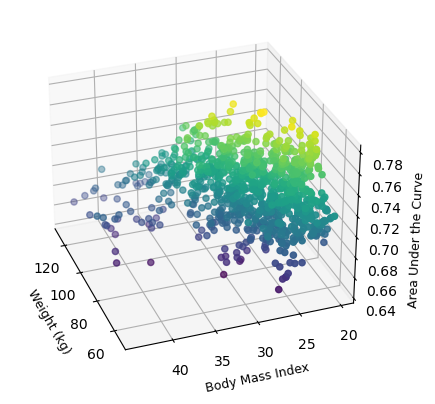

In [6]:
fig = plt.figure()  
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(x2[:1000, 2], x2[:1000, 3], areas, c=areas, cmap='viridis')
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Body Mass Index')
ax.set_zlabel('Area Under the Curve')
ax.grid(True)
ax.set_facecolor('white')  # Adjust background color
ax.view_init(elev=30, azim=160)  # elevation and azimuth
plt.savefig('nhanes_2_roc.png', bbox_inches='tight', pad_inches=0)

<Figure size 640x480 with 0 Axes>